In [1]:
import numpy as np
import pandas as pd
import openpyxl


In [3]:
aml_fraud_customer_profiling = pd.read_csv("data/aml_fraud_customer_profiling.csv")
aml_fraud_customer_profiling.head()

,Unique_Name,Country,Country_Risk_Score,Transaction_Amount,Transaction_Volume_30D,Transaction_Trend_30D,Previous_Banking_History_Score,Chargeback_Count_12M,Past_SAR_Flag,Account_Age_Days,...,Risk_Target,Risk_Label,Country_Risk_Flag,Composite_Risk_Score,Country_Risk_Score_Squared,Transaction_Amount_Cubed,History_Inverse_Squared,Amount_x_CountryRisk,Amount_x_Trend,Volume_x_CountryRisk
0,AML_Customer_00001,DE,0.17,4113.45,24,-0.190,77.47,2,0,2914,...,0,Low_Risk,0,0.290575,0.0289,69.6015,507.6009,699.29,-781.555,4.08
1,AML_Customer_00002,PK,0.55,4329.12,20,0.663,100.00,0,1,3091,...,0,Low_Risk,1,0.555063,0.3025,81.1332,0.0000,2381.02,2870.207,11.00
2,AML_Customer_00003,BR,0.40,7891.34,23,-0.051,41.04,2,1,3371,...,0,Low_Risk,0,0.513282,0.1600,491.4194,3476.2816,3156.54,-402.458,9.20
3,AML_Customer_00004,IN,0.35,14290.72,26,0.325,56.47,1,0,1640,...,1,High_Risk,0,0.618290,0.1225,2918.5177,1894.8609,5001.75,4644.484,9.10
4,AML_Customer_00005,UK,0.18,24675.96,18,-0.576,57.21,3,0,3519,...,0,Low_Risk,0,0.500040,0.0324,15025.2661,1830.9841,4441.67,-14213.353,3.24


In [4]:
aml_fraud_customer_profiling2 = aml_fraud_customer_profiling.copy()
aml_fraud_customer_profiling2.shape,aml_fraud_customer_profiling.shape

((2000, 27), (2000, 27))

In [ ]:
# aml_fraud_customer_profiling2 = aml_fraud_customer_profiling, create a model that is underfitting and then create a model that is overfitting and then create a model that is just right.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Use the dataframe that already exists in the notebook
df = aml_fraud_customer_profiling2.copy()
y = df["Risk_Target"]

# 1) Underfitting: too simple
simple_features = ["Country_Risk_Score"]

# 2) Just right: enough useful original features
good_features = [
    "Country_Risk_Score",
    "Transaction_Amount",
    "Transaction_Volume_30D",
    "Transaction_Trend_30D",
    "Previous_Banking_History_Score",
    "Chargeback_Count_12M",
    "Past_SAR_Flag",
    "Account_Age_Days",
    "KYC_Risk_Score",
]

# 3) Overfitting: too many numeric features + polynomial expansion
complex_features = df.select_dtypes(include=[np.number]).columns.drop("Risk_Target").tolist()

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

underfit_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=0.01, max_iter=5000)
)
underfit_model.fit(df.loc[train_idx, simple_features], y_train)

overfit_model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LogisticRegression(C=1e6, max_iter=10000)
)
overfit_model.fit(df.loc[train_idx, complex_features], y_train)

just_right_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=5000)
)
just_right_model.fit(df.loc[train_idx, good_features], y_train)

results = []

for name, model, features, explanation in [
    (
        "Underfitting",
        underfit_model,
        simple_features,
        "This model is too simple. It uses only 1 feature, so it misses important patterns."
    ),
    (
        "Overfitting",
        overfit_model,
        complex_features,
        "This model is too complex. It uses many features and polynomial terms, so it can memorize the training data."
    ),
    (
        "Just Right",
        just_right_model,
        good_features,
        "This model is balanced. It uses useful features without making the model too complex."
    ),
]:
    train_acc = accuracy_score(y_train, model.predict(df.loc[train_idx, features]))
    test_acc = accuracy_score(y_test, model.predict(df.loc[test_idx, features]))

    results.append({
        "Model": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Gap": round(train_acc - test_acc, 4),
        "Simple Explanation": explanation
    })

results_df = pd.DataFrame(results)
print(results_df)

print("\nSimple meaning:")
print("- Underfitting = model is too simple, so it does badly on both training and test data.")
print("- Overfitting = model does very well on training data, but worse on test data because it memorized too much.")
print("- Just right = model performs well on both training and test data, with a small gap between them.")

          Model  Train Accuracy  Test Accuracy     Gap  \
0  Underfitting          0.8206         0.8200  0.0006   
1   Overfitting          1.0000         0.9675  0.0325   
2    Just Right          0.9150         0.9125  0.0025   

                                  Simple Explanation  
0  This model is too simple. It uses only 1 featu...  
1  This model is too complex. It uses many featur...  
2  This model is balanced. It uses useful feature...  

Simple meaning:
- Underfitting = model is too simple, so it does badly on both training and test data.
- Overfitting = model does very well on training data, but worse on test data because it memorized too much.
- Just right = model performs well on both training and test data, with a small gap between them.


Standard Logistic Regression Cost Function:
J(θ) = -(1/m) * Σ [ y log(hθ(x)) + (1-y) log(1-hθ(x)) ]

Regularized Logistic Regression Cost Function:
J(θ) = -(1/m) * Σ [ y log(hθ(x)) + (1-y) log(1-hθ(x)) ] + (λ / 2m) * Σ θ_j^2

Simple meaning:
- The first part measures prediction error.
- The regularization part adds a penalty when coefficients become too large.
- This penalty helps stop the model from becoming too complex.
- Important note: the intercept term is usually not penalized.
- In scikit-learn, C is the inverse of regularization strength.
  So:
  * small C  -> strong regularization
  * large C  -> weak regularization

Simple examples from this run:
- Strong regularization example (C=0.0001): train=0.7125, test=0.7100, gap=0.0025
  This can underfit because the model is forced to stay too simple.

- Best balance example (C=21.54): train=0.9750, test=0.9700, gap=0.0050
  This is the 'just right' zone: good test performance with a small gap.

- Weak regularization example (C=1e+04

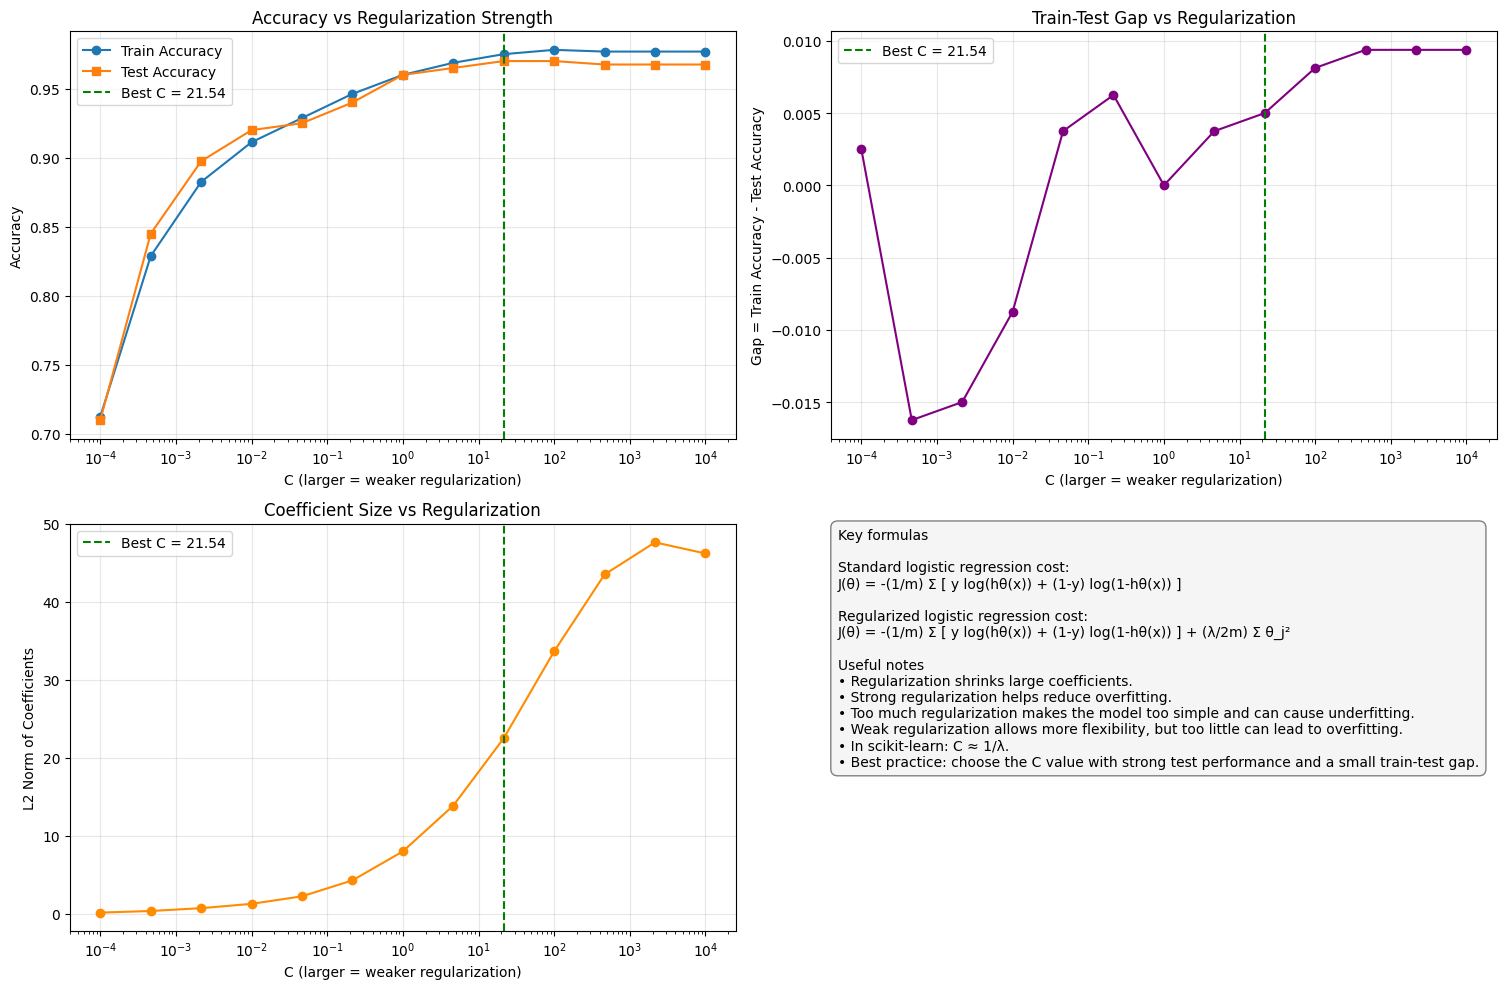


Best regularization setting found:
C                                                                21.544347
Approx_Lambda_1_over_C                                            0.046416
Train_Accuracy                                                       0.975
Test_Accuracy                                                         0.97
Gap                                                                  0.005
Coefficient_Norm                                                 22.495037
Interpretation            Balanced regularization -> better generalization
Name: 8, dtype: object


,C,Approx_Lambda_1_over_C,Train_Accuracy,Test_Accuracy,Gap,Coefficient_Norm,Interpretation
0,0.000100,10000.000000,0.7125,0.7100,0.0025,0.1157,Very strong regularization -> model may underfit
1,0.000464,2154.434690,0.8288,0.8450,-0.0162,0.3230,Very strong regularization -> model may underfit
2,0.002154,464.158883,0.8825,0.8975,-0.0150,0.6862,Very strong regularization -> model may underfit
3,0.010000,100.000000,0.9112,0.9200,-0.0088,1.2406,Very strong regularization -> model may underfit
4,0.046416,21.544347,0.9288,0.9250,0.0037,2.2075,Balanced regularization -> better generalization
5,0.215443,4.641589,0.9462,0.9400,0.0063,4.2556,Balanced regularization -> better generalization
6,1.000000,1.000000,0.9600,0.9600,0.0000,7.9738,Balanced regularization -> better generalization
7,4.641589,0.215443,0.9688,0.9650,0.0038,13.8489,Balanced regularization -> better generalization
8,21.544347,0.046416,0.9750,0.9700,0.0050,22.4950,Balanced regularization -> better generalization
9,100.000000,0.010000,0.9781,0.9700,0.0081,33.6556,Balanced regularization -> better generalization


In [8]:
import matplotlib.pyplot as plt

# This cell explains regularization in a practical way using logistic regression.
# Idea:
# 1. We intentionally make the model more flexible with polynomial features.
# 2. We then change C, which controls regularization strength in scikit-learn.
#    - Small C  = strong regularization = simpler model = can underfit
#    - Large C  = weak regularization   = more flexible model = can overfit
# 3. We compare train/test accuracy to find a balanced point.

# We reuse variables that already exist in the notebook:
# df, y_train, y_test, train_idx, test_idx, good_features

# Use a moderate set of useful features, then expand them with polynomial terms.
# This gives the logistic regression enough flexibility so regularization matters.
X_train = df.loc[train_idx, good_features]
X_test = df.loc[test_idx, good_features]

# Try a wide range of C values on a log scale.
# In scikit-learn, C is the inverse of lambda:
#   lambda large  -> C small  -> stronger regularization
#   lambda small  -> C large  -> weaker regularization
regularization_C_values = np.logspace(-4, 4, 13)

regularization_results = []
regularization_models = {}

for c in regularization_C_values:
    reg_model = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        LogisticRegression(C=c, max_iter=10000)
    )

    reg_model.fit(X_train, y_train)

    train_pred = reg_model.predict(X_train)
    test_pred = reg_model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    gap = train_accuracy - test_accuracy

    # Coefficient size is useful for understanding regularization.
    # Stronger regularization usually shrinks coefficients more.
    coef_norm = np.linalg.norm(reg_model.named_steps["logisticregression"].coef_)

    if c <= 0.01:
        interpretation = "Very strong regularization -> model may underfit"
    elif gap > 0.02:
        interpretation = "Weak regularization -> model may overfit"
    else:
        interpretation = "Balanced regularization -> better generalization"

    regularization_results.append({
        "C": c,
        "Approx_Lambda_1_over_C": 1 / c,
        "Train_Accuracy": train_accuracy,
        "Test_Accuracy": test_accuracy,
        "Gap": gap,
        "Coefficient_Norm": coef_norm,
        "Interpretation": interpretation
    })

    regularization_models[c] = reg_model

regularization_results_df = pd.DataFrame(regularization_results)

# Best balance:
# pick the row with the highest test accuracy, then prefer the smaller gap
best_regularized_row = (
    regularization_results_df
    .sort_values(["Test_Accuracy", "Gap"], ascending=[False, True])
    .iloc[0]
)

best_c = best_regularized_row["C"]

# Representative examples for simple explanation
strong_reg_row = regularization_results_df.iloc[0]    # smallest C
weak_reg_row = regularization_results_df.iloc[-1]     # largest C

print("Standard Logistic Regression Cost Function:")
print(r"J(θ) = -(1/m) * Σ [ y log(hθ(x)) + (1-y) log(1-hθ(x)) ]")
print()
print("Regularized Logistic Regression Cost Function:")
print(r"J(θ) = -(1/m) * Σ [ y log(hθ(x)) + (1-y) log(1-hθ(x)) ] + (λ / 2m) * Σ θ_j^2")
print()
print("Simple meaning:")
print("- The first part measures prediction error.")
print("- The regularization part adds a penalty when coefficients become too large.")
print("- This penalty helps stop the model from becoming too complex.")
print("- Important note: the intercept term is usually not penalized.")
print("- In scikit-learn, C is the inverse of regularization strength.")
print("  So:")
print("  * small C  -> strong regularization")
print("  * large C  -> weak regularization")
print()

print("Simple examples from this run:")
print(f"- Strong regularization example (C={strong_reg_row['C']:.4g}): "
      f"train={strong_reg_row['Train_Accuracy']:.4f}, "
      f"test={strong_reg_row['Test_Accuracy']:.4f}, "
      f"gap={strong_reg_row['Gap']:.4f}")
print("  This can underfit because the model is forced to stay too simple.")
print()

print(f"- Best balance example (C={best_c:.4g}): "
      f"train={best_regularized_row['Train_Accuracy']:.4f}, "
      f"test={best_regularized_row['Test_Accuracy']:.4f}, "
      f"gap={best_regularized_row['Gap']:.4f}")
print("  This is the 'just right' zone: good test performance with a small gap.")
print()

print(f"- Weak regularization example (C={weak_reg_row['C']:.4g}): "
      f"train={weak_reg_row['Train_Accuracy']:.4f}, "
      f"test={weak_reg_row['Test_Accuracy']:.4f}, "
      f"gap={weak_reg_row['Gap']:.4f}")
print("  This can overfit because the model is allowed to become too flexible.")

# ----------------------------
# Visuals
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Train vs test accuracy
axes[0, 0].plot(
    regularization_results_df["C"],
    regularization_results_df["Train_Accuracy"],
    marker="o",
    label="Train Accuracy"
)
axes[0, 0].plot(
    regularization_results_df["C"],
    regularization_results_df["Test_Accuracy"],
    marker="s",
    label="Test Accuracy"
)
axes[0, 0].axvline(best_c, color="green", linestyle="--", label=f"Best C = {best_c:.4g}")
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("Accuracy vs Regularization Strength")
axes[0, 0].set_xlabel("C (larger = weaker regularization)")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2) Overfitting gap
axes[0, 1].plot(
    regularization_results_df["C"],
    regularization_results_df["Gap"],
    marker="o",
    color="purple"
)
axes[0, 1].axvline(best_c, color="green", linestyle="--", label=f"Best C = {best_c:.4g}")
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Train-Test Gap vs Regularization")
axes[0, 1].set_xlabel("C (larger = weaker regularization)")
axes[0, 1].set_ylabel("Gap = Train Accuracy - Test Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3) Coefficient size
axes[1, 0].plot(
    regularization_results_df["C"],
    regularization_results_df["Coefficient_Norm"],
    marker="o",
    color="darkorange"
)
axes[1, 0].axvline(best_c, color="green", linestyle="--", label=f"Best C = {best_c:.4g}")
axes[1, 0].set_xscale("log")
axes[1, 0].set_title("Coefficient Size vs Regularization")
axes[1, 0].set_xlabel("C (larger = weaker regularization)")
axes[1, 0].set_ylabel("L2 Norm of Coefficients")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4) Formula and notes panel
axes[1, 1].axis("off")
formula_and_notes = (
    "Key formulas\n\n"
    "Standard logistic regression cost:\n"
    "J(θ) = -(1/m) Σ [ y log(hθ(x)) + (1-y) log(1-hθ(x)) ]\n\n"
    "Regularized logistic regression cost:\n"
    "J(θ) = -(1/m) Σ [ y log(hθ(x)) + (1-y) log(1-hθ(x)) ] + (λ/2m) Σ θ_j²\n\n"
    "Useful notes\n"
    "• Regularization shrinks large coefficients.\n"
    "• Strong regularization helps reduce overfitting.\n"
    "• Too much regularization makes the model too simple and can cause underfitting.\n"
    "• Weak regularization allows more flexibility, but too little can lead to overfitting.\n"
    "• In scikit-learn: C ≈ 1/λ.\n"
    "• Best practice: choose the C value with strong test performance and a small train-test gap."
)
axes[1, 1].text(
    0.01, 0.99, formula_and_notes,
    va="top", ha="left", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5", edgecolor="gray")
)

plt.tight_layout()
plt.show()

# Helpful summary table for inspection
regularization_results_df = regularization_results_df.sort_values("C").reset_index(drop=True)
regularization_results_df[["Train_Accuracy", "Test_Accuracy", "Gap", "Coefficient_Norm"]] = (
    regularization_results_df[["Train_Accuracy", "Test_Accuracy", "Gap", "Coefficient_Norm"]].round(4)
)

print("\nBest regularization setting found:")
print(best_regularized_row)

regularization_results_df